In [53]:
# Phase 1 - Exploratory Data Analysis (EDA)

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [55]:
#1.Loading the dataset

data = pd.read_csv( "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/VerbAgg.csv")
data.head(20)

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
0,1,20,M,S1WantCurse,no,1,curse,other,want,N
1,2,11,M,S1WantCurse,no,2,curse,other,want,N
2,3,17,F,S1WantCurse,perhaps,3,curse,other,want,Y
3,4,21,F,S1WantCurse,perhaps,4,curse,other,want,Y
4,5,17,F,S1WantCurse,perhaps,5,curse,other,want,Y
5,6,21,F,S1WantCurse,yes,6,curse,other,want,Y
6,7,39,F,S1WantCurse,yes,7,curse,other,want,Y
7,8,21,F,S1WantCurse,no,8,curse,other,want,N
8,9,24,F,S1WantCurse,no,9,curse,other,want,N
9,10,16,F,S1WantCurse,yes,10,curse,other,want,Y


In [56]:
#2.Applying basic statistical analysis

print("Shape of the Dataset:")
print(data.shape)


print("\nColumn Names:")
print(data.columns)


print("\nDataset Information:")
data.info()


print("\nStatistical Summary:")
print(data.describe())


print("\nMean:")
print(data.mean(numeric_only=True))


print("\nMedian:")
print(data.median(numeric_only=True))


print("\nMode:")
print(data.mode())


print("\nStandard Deviation:")
print(data.std(numeric_only=True))


print("\nMinimum Values:")
print(data.min(numeric_only=True))


print("\nMaximum Values:")
print(data.max(numeric_only=True))


print("\nNumber of Unique Values:")
print(data.nunique())


print("\nColumn Names:")
print(data.columns)


print("\nData Types:")
print(data.dtypes)





Shape of the Dataset:
(7584, 10)

Column Names:
Index(['rownames', 'Anger', 'Gender', 'item', 'resp', 'id', 'btype', 'situ',
       'mode', 'r2'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7584 entries, 0 to 7583
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  7584 non-null   int64 
 1   Anger     7584 non-null   int64 
 2   Gender    7584 non-null   object
 3   item      7584 non-null   object
 4   resp      7584 non-null   object
 5   id        7584 non-null   int64 
 6   btype     7584 non-null   object
 7   situ      7584 non-null   object
 8   mode      7584 non-null   object
 9   r2        7584 non-null   object
dtypes: int64(3), object(7)
memory usage: 592.6+ KB

Statistical Summary:
          rownames        Anger         id
count  7584.000000  7584.000000  7584.0000
mean   3792.500000    20.003165   158.5000
std    2189.456554     4.841139    91.2269


In [57]:
#3 Handling Missing Data

print("Missing Values:")
print(data.isnull().sum())

print("\nNon-Missing Values:")
print(data.notnull().sum())


print("\nTotal Missing Values:")
print(data.isnull().sum().sum())


print("\nCount of Non-Missing Values:")
print(data.count())


data_drop = data.dropna()

print("\nShape After dropna():")
print(data_drop.shape)

data_fill = data.fillna(0)

print("\nMissing Values After fillna():")
print(data_fill.isnull().sum())


data_ffill = data.ffill()

print("\nMissing Values After Forward Fill:")
print(data_ffill.isnull().sum())


data_bfill = data.bfill()

print("\nMissing Values After Backward Fill:")
print(data_bfill.isnull().sum())

Missing Values:
rownames    0
Anger       0
Gender      0
item        0
resp        0
id          0
btype       0
situ        0
mode        0
r2          0
dtype: int64

Non-Missing Values:
rownames    7584
Anger       7584
Gender      7584
item        7584
resp        7584
id          7584
btype       7584
situ        7584
mode        7584
r2          7584
dtype: int64

Total Missing Values:
0

Count of Non-Missing Values:
rownames    7584
Anger       7584
Gender      7584
item        7584
resp        7584
id          7584
btype       7584
situ        7584
mode        7584
r2          7584
dtype: int64

Shape After dropna():
(7584, 10)

Missing Values After fillna():
rownames    0
Anger       0
Gender      0
item        0
resp        0
id          0
btype       0
situ        0
mode        0
r2          0
dtype: int64

Missing Values After Forward Fill:
rownames    0
Anger       0
Gender      0
item        0
resp        0
id          0
btype       0
situ        0
mode        0
r2      

In [58]:
#4 Data cleaning

print("Number of Duplicate Rows:")
print(data.duplicated().sum())

data = data.drop_duplicates()

print("\nNumber of Duplicate Rows After Cleaning:")
print(data.duplicated().sum())



Number of Duplicate Rows:
0

Number of Duplicate Rows After Cleaning:
0


In [59]:
#5 Data transformation

print("Response Values Before Transformation:")
print(data["resp"].value_counts())

data["resp"] = data["resp"].map({"no": 0,"perhaps": 1,"yes": 2})

print("\nResponse Values After Transformation:")
print(data["resp"].value_counts())

Response Values Before Transformation:
resp
no         3973
perhaps    2081
yes        1530
Name: count, dtype: int64

Response Values After Transformation:
resp
0    3973
1    2081
2    1530
Name: count, dtype: int64


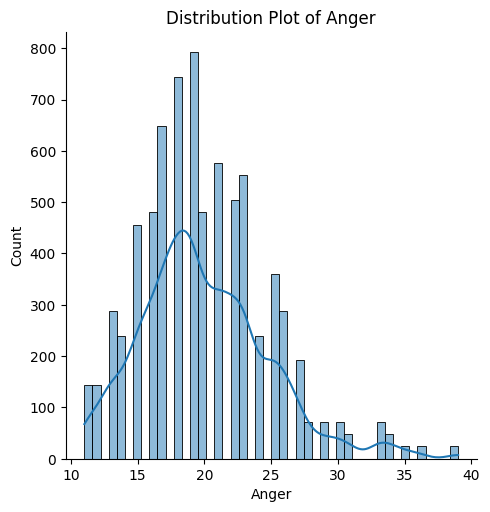

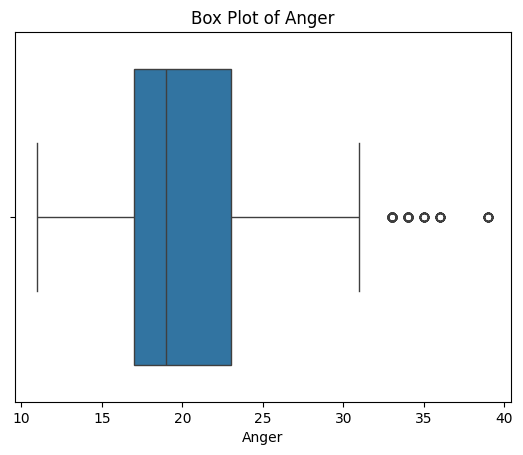

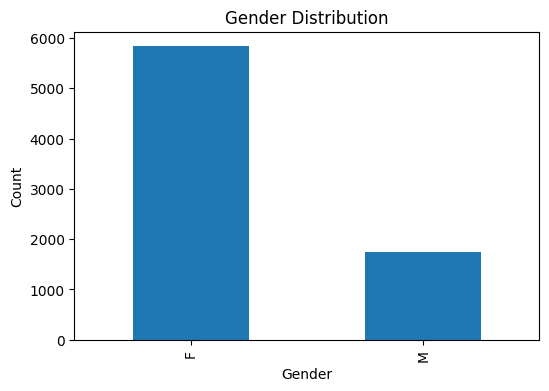

In [60]:
#6 Univariate analysis with a minimum of three visualizations

sns.displot(data["Anger"], kde=True)
plt.title("Distribution Plot of Anger")
plt.show()
print("\n")

sns.boxplot(x="Anger", data=data)
plt.title("Box Plot of Anger")
plt.show()
print("\n")

data["Gender"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

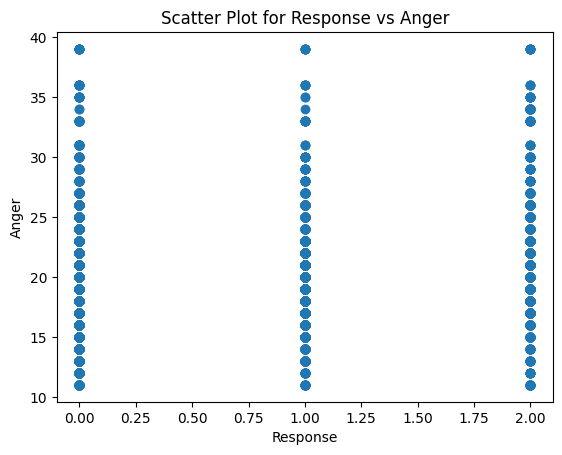

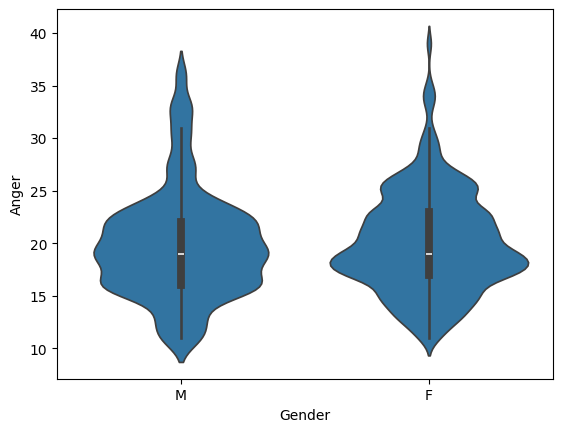

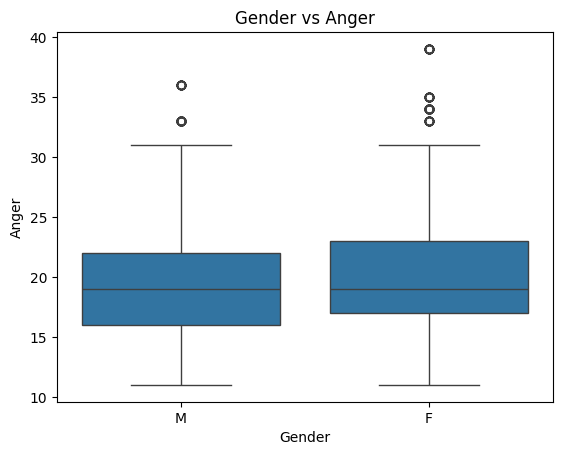

In [61]:
#7 Bivariate analysis with a minimum of three visualizations

plt.scatter(data["resp"], data["Anger"])
plt.title("Scatter Plot for Response vs Anger")
plt.xlabel("Response")
plt.ylabel("Anger")
plt.show()
print("\n")

sns.violinplot(x="Gender", y="Anger", data=data)
plt.show()
print("\n")

sns.boxplot(x="Gender", y="Anger", data=data)
plt.title("Gender vs Anger")
plt.show()

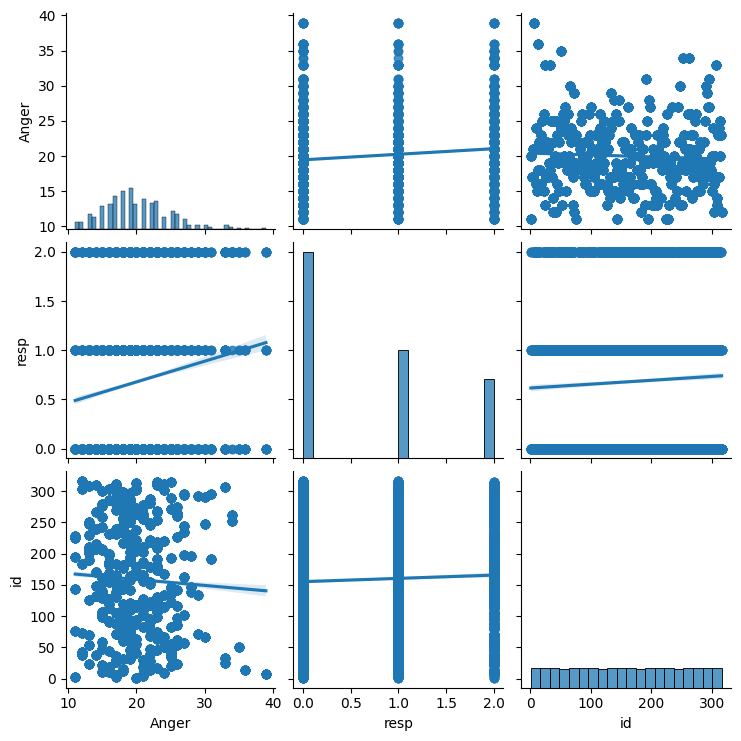

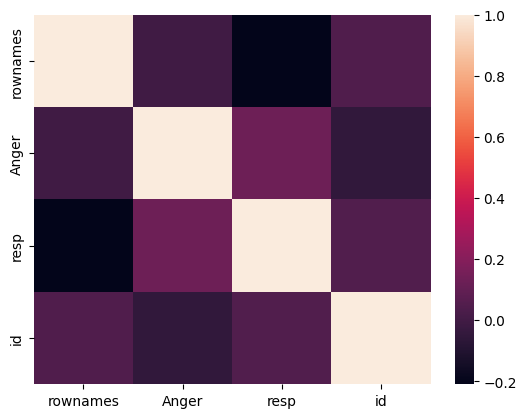

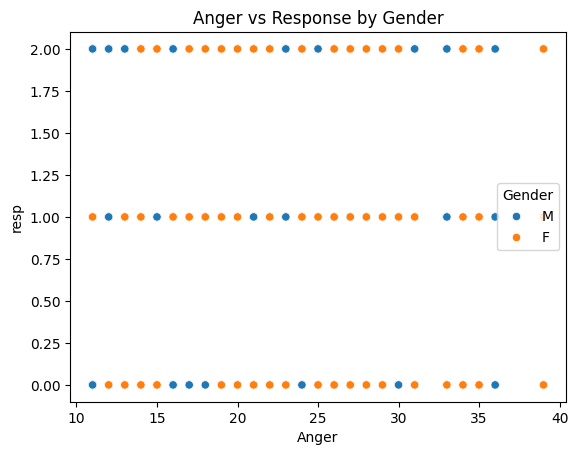

In [62]:
#8 Multivariate analysis with a minimum of three visualizations

sns.pairplot(data,vars=["Anger","resp","id"],kind="reg")
plt.show()
print("\n")

correlation = data.corr(method="pearson", numeric_only=True)
sns.heatmap(correlation,xticklabels=correlation.columns,yticklabels=correlation.columns)
plt.show()
print("\n")


sns.scatterplot(x="Anger",y="resp",hue="Gender",data=data)
plt.title("Anger vs Response by Gender")
plt.show()




In [63]:
#Phase 2

In [64]:
# 1D Statistical Analysis

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = data.select_dtypes(include=np.number).columns

statistics_1d = pd.DataFrame({
    "Mean": data[numeric_columns].mean(),
    "Median": data[numeric_columns].median(),
    "Mode": data[numeric_columns].mode().iloc[0],
    "Variance": data[numeric_columns].var(),
    "Standard Deviation": data[numeric_columns].std(),
    "Minimum": data[numeric_columns].min(),
    "Maximum": data[numeric_columns].max(),
    "Range": data[numeric_columns].max() - data[numeric_columns].min(),
    "Q1": data[numeric_columns].quantile(0.25),
    "Q3": data[numeric_columns].quantile(0.75),
    "IQR": data[numeric_columns].quantile(0.75) - data[numeric_columns].quantile(0.25),
    "Skewness": data[numeric_columns].skew(),
    "Kurtosis": data[numeric_columns].kurtosis()
})

display(statistics_1d)

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Maximum,Range,Q1,Q3,IQR,Skewness,Kurtosis
rownames,3792.500000,3792.5,1.0,4.793720e+06,2189.456554,1,7584,7583,1896.75,5688.25,3791.5,0.000000,-1.200000
Anger,20.003165,19.0,19.0,2.343662e+01,4.841139,11,39,28,17.00,23.00,6.0,0.725483,0.887055
resp,0.677874,0.0,0.0,6.219237e-01,0.788621,0,2,2,0.00,1.00,1.0,0.636862,-1.112110
id,158.500000,158.5,1.0,8.322347e+03,91.226900,1,316,315,79.75,237.25,157.5,0.000000,-1.200024


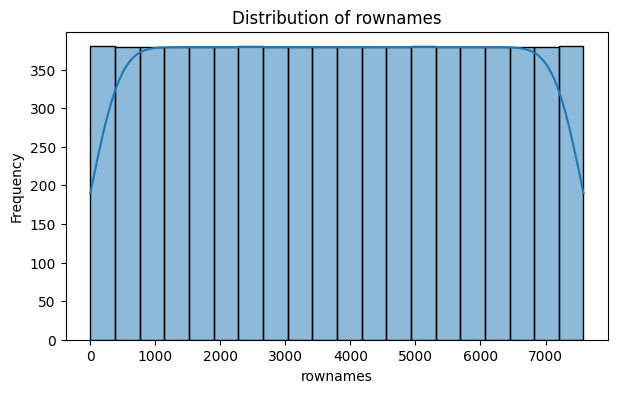

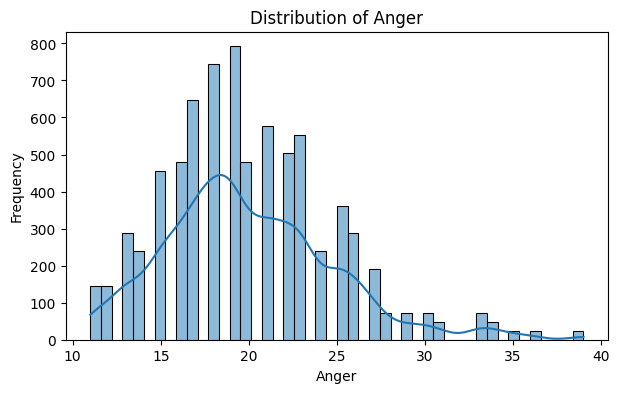

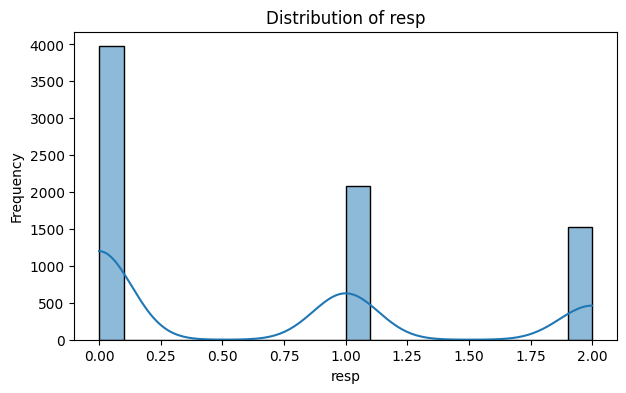

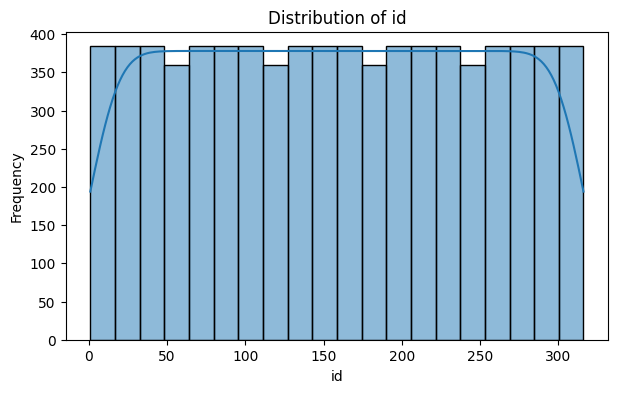

In [66]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

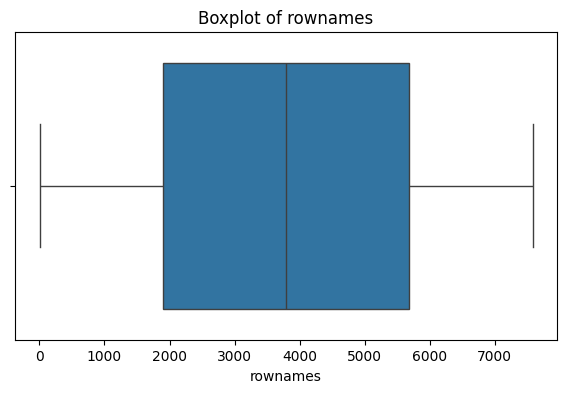

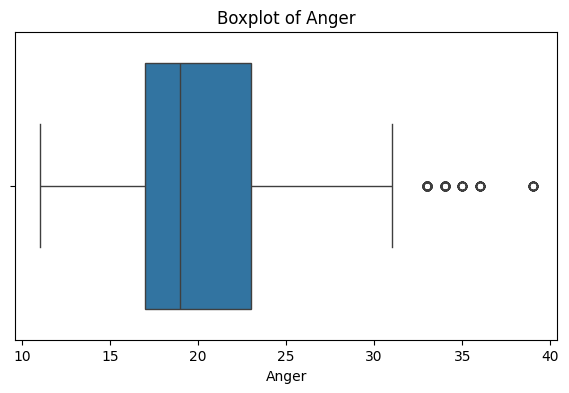

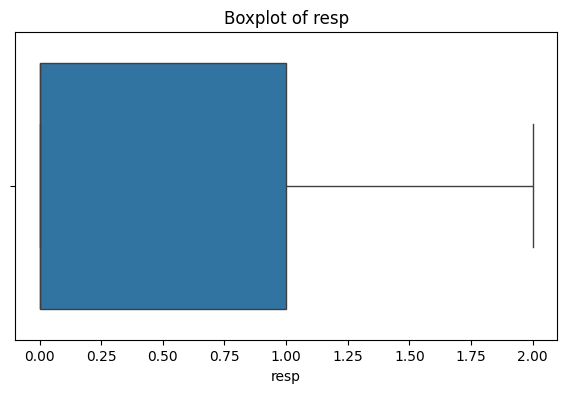

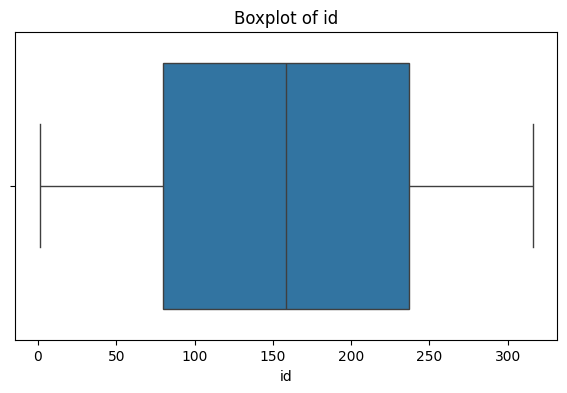

In [67]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=data[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

In [68]:
#2D Statistical Analysis

In [69]:
# Numerical vs Numerical

numerical_pairs = [
    ("Anger", "resp")
]

for x, y in numerical_pairs:
    covariance = data[x].cov(data[y])
    print(f"Covariance between {x} and {y}: {covariance:.4f}")

Covariance between Anger and resp: 0.4922


In [70]:
for x, y in numerical_pairs:
    correlation = data[x].corr(data[y])
    print(f"Correlation between {x} and {y}: {correlation:.4f}")

Correlation between Anger and resp: 0.1289


In [71]:
correlation_matrix = data[numeric_columns].corr()

display(correlation_matrix)

,rownames,Anger,resp,id
rownames,1.000000,-0.002113,-0.209827,0.041666
Anger,-0.002113,1.000000,0.128935,-0.050706
resp,-0.209827,0.128935,1.000000,0.045473
id,0.041666,-0.050706,0.045473,1.000000


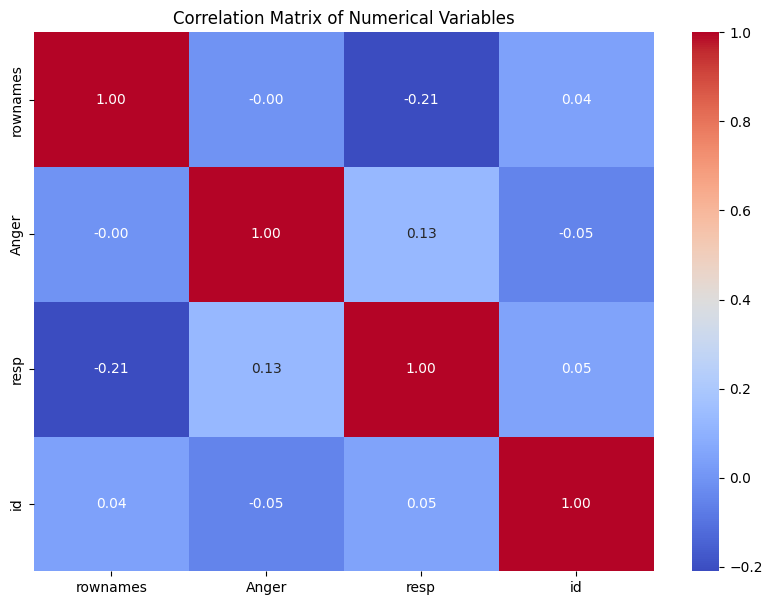

In [72]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

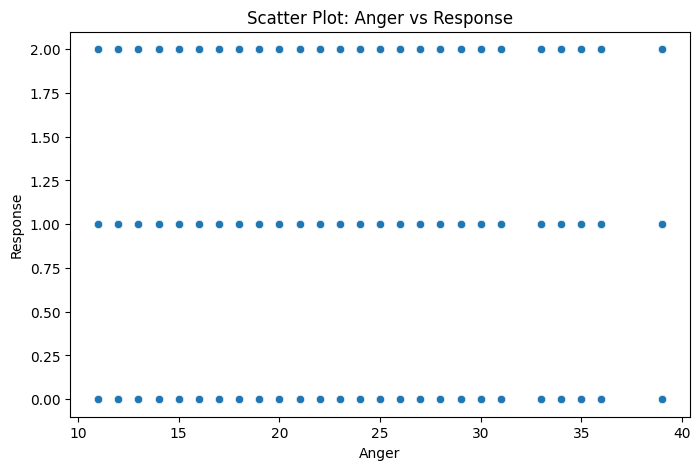

In [73]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Anger",
    y="resp"
)

plt.title("Scatter Plot: Anger vs Response")
plt.xlabel("Anger")
plt.ylabel("Response")

plt.show()

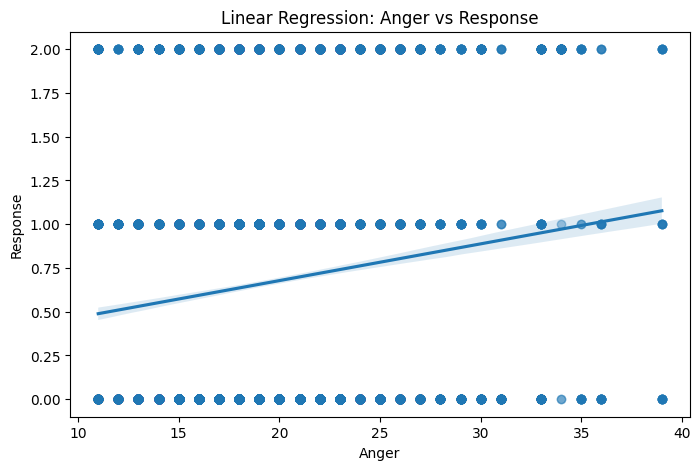

In [74]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=data,
    x="Anger",
    y="resp",
    scatter_kws={"alpha": 0.4}
)

plt.title("Linear Regression: Anger vs Response")
plt.xlabel("Anger")
plt.ylabel("Response")

plt.show()

In [75]:
#Categorical vs Categorical

In [76]:
categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'item', 'btype', 'situ', 'mode', 'r2']


In [77]:
cat1 = "Gender"
cat2 = "mode"

frequency_table = pd.crosstab(
    data[cat1],
    data[cat2]
)

print(f"Frequency Table: {cat1} vs {cat2}")

display(frequency_table)

Frequency Table: Gender vs mode


mode,do,want
Gender,,
F,2916,2916
M,876,876


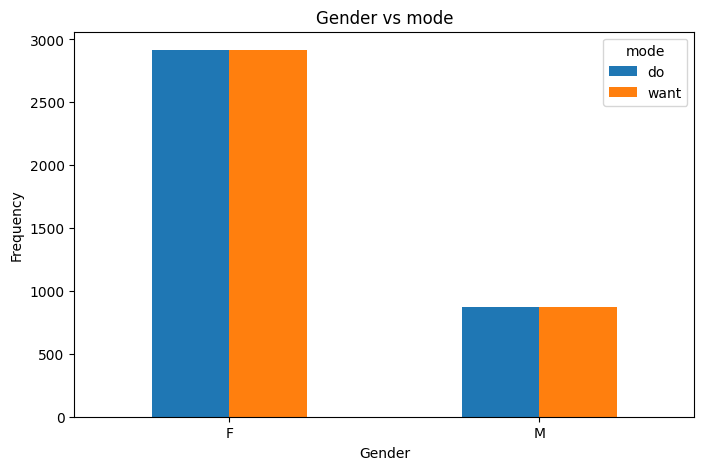

In [78]:
frequency_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(f"{cat1} vs {cat2}")
plt.xlabel(cat1)
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.legend(title=cat2)

plt.show()

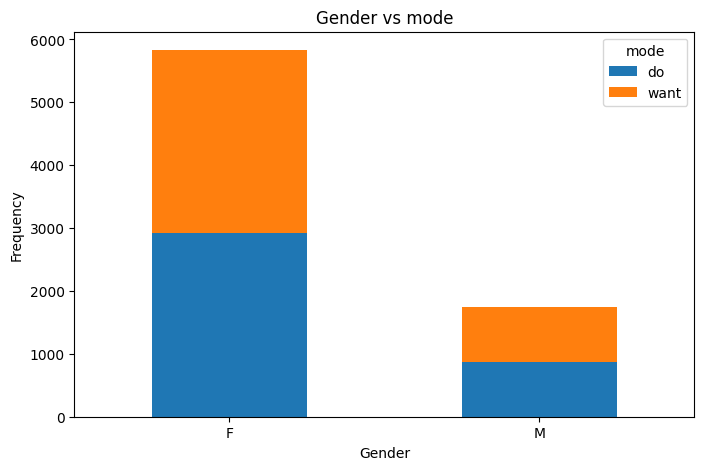

In [79]:
frequency_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title(f"{cat1} vs {cat2}")
plt.xlabel(cat1)
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.legend(title=cat2)

plt.show()

In [80]:
from scipy.stats import chi2_contingency

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    frequency_table
)

print("Chi-Square Test")
print("Chi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", degrees_of_freedom)
print("P-value:", round(p_value, 6))

Chi-Square Test
Chi-square statistic: 0.0
Degrees of freedom: 1
P-value: 1.0


In [81]:
#Categorical vs Numerical

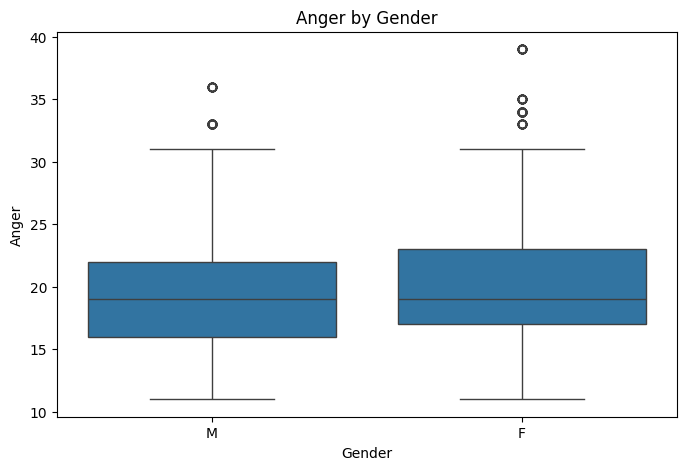

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Gender",
    y="Anger"
)

plt.title("Anger by Gender")
plt.xlabel("Gender")
plt.ylabel("Anger")

plt.show()

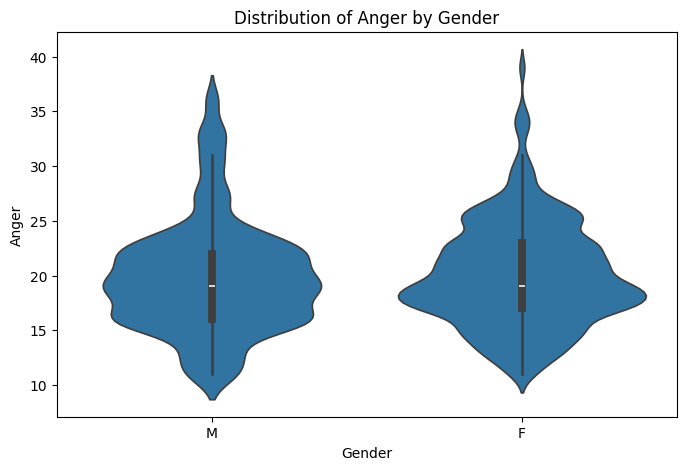

In [83]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=data,
    x="Gender",
    y="Anger"
)

plt.title("Distribution of Anger by Gender")
plt.xlabel("Gender")
plt.ylabel("Anger")

plt.show()

In [84]:
#K-means Clustering

In [85]:
# Select numerical features

numeric_features = data.select_dtypes(include=np.number).columns

print("Numerical features:")
print(numeric_features.tolist())

X = data[numeric_features]

display(X.head())

Numerical features:
['rownames', 'Anger', 'resp', 'id']


,rownames,Anger,resp,id
0,1,20,0,1
1,2,11,0,2
2,3,17,1,3
3,4,21,1,4
4,5,17,1,5


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [87]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data["KMeans_Cluster"] = clusters

In [88]:
display(data[["KMeans_Cluster"]].head())

,KMeans_Cluster
0,1
1,1
2,0
3,0
4,0


In [89]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=numeric_features
)

display(cluster_centers)

,rownames,Anger,resp,id
0,-0.516950,0.202873,1.083338,0.057272
1,0.310344,-0.121792,-0.650369,-0.034383


In [90]:
wcss = []

for k in range(1, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_temp.fit(X_scaled)

    wcss.append(kmeans_temp.inertia_)

display(
    pd.DataFrame({
        "K": range(1, 11),
        "WCSS": wcss
    })
)

,K,WCSS
0,1,30336.000000
1,2,23573.352329
2,3,19488.195752
3,4,17011.897966
4,5,15052.405263
5,6,13541.080026
6,7,12536.083930
7,8,11601.049249
8,9,10781.907921
9,10,10125.419538


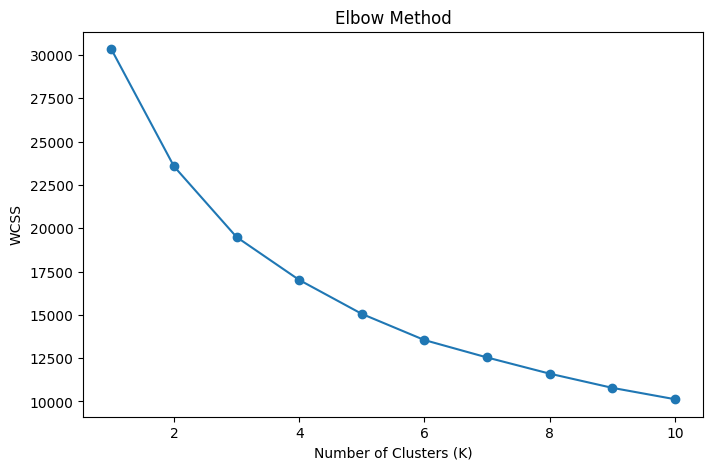

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [92]:
# Hierarchical clustering.

In [93]:
from scipy.spatial.distance import pdist

dist = pdist(X_scaled, metric="euclidean")

print(dist[:10])

[1.85922168 1.41162065 1.28525627 1.41213224 2.54522865 4.67355459
 0.22039203 0.83095529 2.6692768  1.63921073]


In [94]:
#Single Linkage
from scipy.cluster.hierarchy import linkage, dendrogram

hc_single = linkage(
    X_scaled,
    method="single",
    metric="euclidean"
)

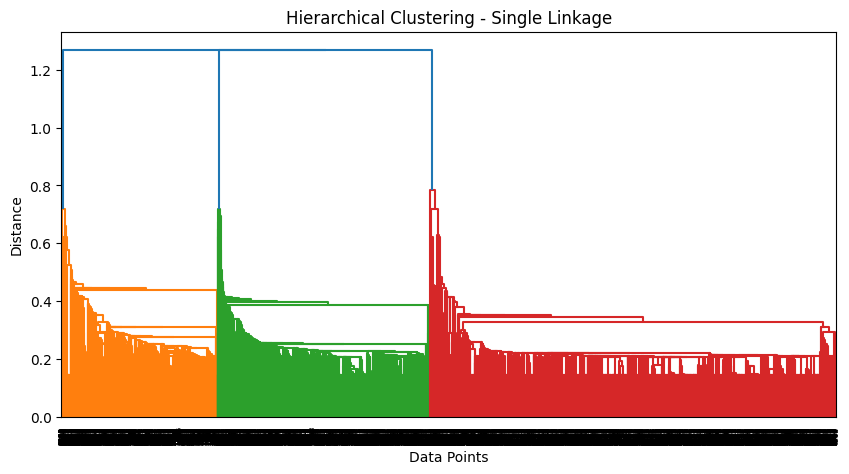

In [95]:
plt.figure(figsize=(10, 5))

dendrogram(hc_single)

plt.title("Hierarchical Clustering - Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [96]:
#Complete Linkage
hc_complete = linkage(
    X_scaled,
    method="complete",
    metric="euclidean"
)

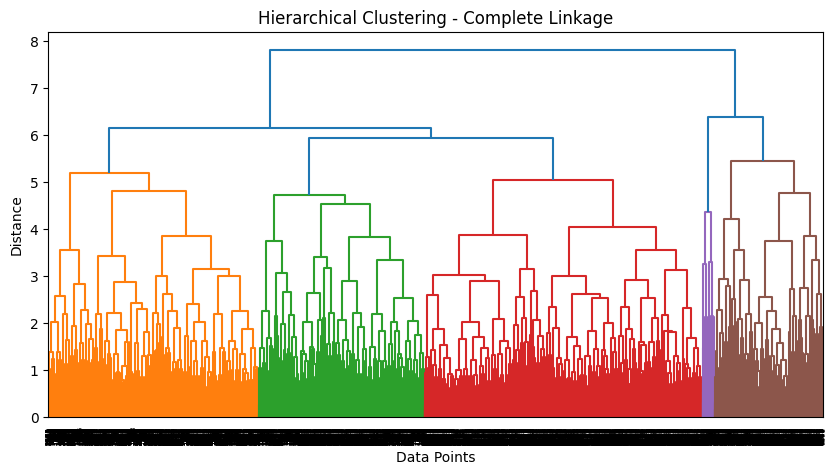

In [97]:
plt.figure(figsize=(10, 5))

dendrogram(hc_complete)

plt.title("Hierarchical Clustering - Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [98]:
#Average Linkage
hc_average = linkage(
    X_scaled,
    method="average",
    metric="euclidean"
)


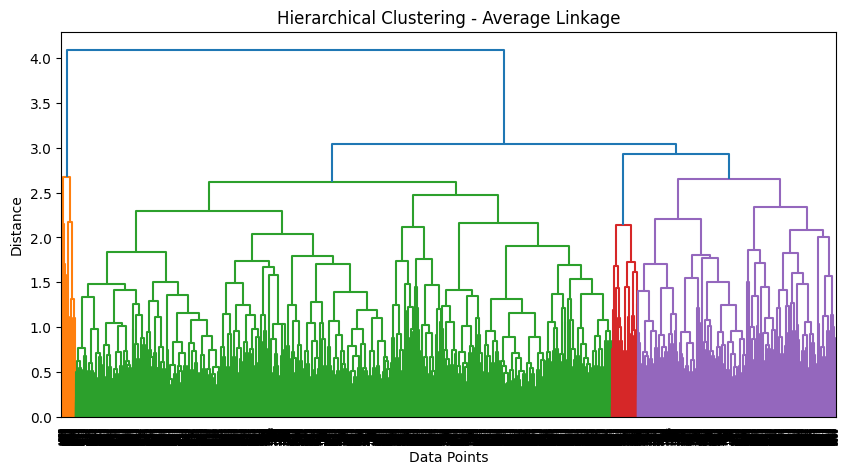

In [99]:
plt.figure(figsize=(10, 5))

dendrogram(hc_average)

plt.title("Hierarchical Clustering - Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [101]:
#Ward's Method
hc_ward = linkage(
    X_scaled,
    method="ward"
)

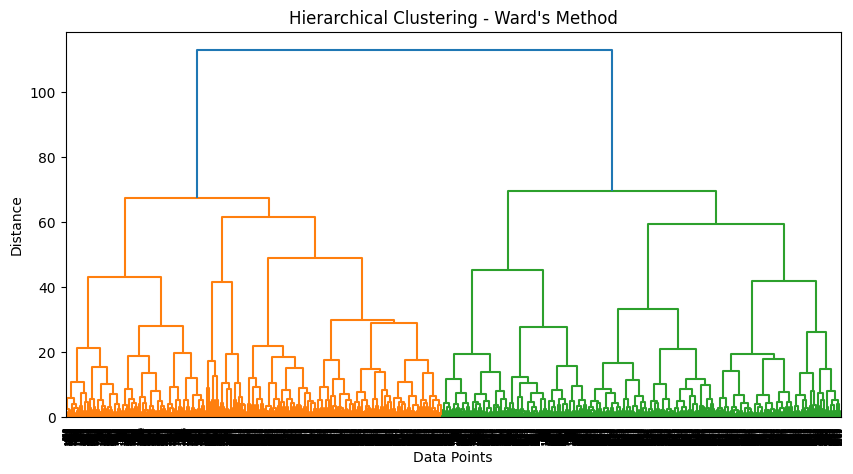

In [102]:
plt.figure(figsize=(10, 5))

dendrogram(hc_ward)

plt.title("Hierarchical Clustering - Ward's Method")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()